In [3]:
#pip install keras

In [4]:
#pip install tensorflow

## 1. Import the Necessary Library

In [5]:
import keras
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

## 2. Data Collection 

In [11]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data(path="mnist.npz")

In [13]:
X_train.shape,y_train.shape

((60000, 28, 28), (60000,))

In [14]:
X_test.shape,y_test.shape

((10000, 28, 28), (10000,))

In [18]:

assert X_train.shape == (60000, 28, 28)
assert X_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)


## 3 Check the Image from Data Set

In [19]:
pd.set_option('display.max_columns', 30)

In [23]:
pd.DataFrame(X_train[150])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,19,221,254,11,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,139,253,227,8,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,135,254,253,63,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,4,138,252,254,253,44,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,3,138,253,253,254,253,44,0,0,0,0,0,0,0,0,0,0


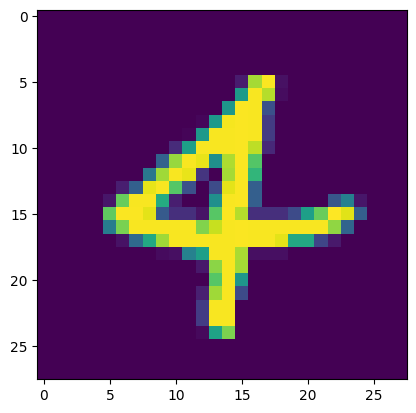

In [24]:
plt.imshow(X_train[150])

## 4. Data Preparation

#### Normaile the Data

In [27]:
X_train.min(),X_test.max()

(np.uint8(0), np.uint8(255))

In [28]:
X_train = X_train/255.0
X_test = X_test/255.0

In [29]:
X_train.min(),X_test.max()

(np.float64(0.0), np.float64(1.0))

## 5. Module Building

In [30]:
from keras.models import Sequential
from keras.layers import Flatten,Dense

In [31]:
model = Sequential()

In [35]:
model.add(layer= Flatten()) ## Input Layer
model.add(layer= Dense(units = 100,activation="relu")) ## Hidden Layer 1
model.add(layer=Dense(units = 10,activation="softmax")) ## Output Layer

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
## Complie the Modile after architect'
model.compile(optimizer="rmsprop",loss="SparseCategoricalCrossentropy",metrics=["sparse_categorical_accuracy"])

## 6. Module Trining | Module Test | Module Evaluation

In [45]:
model.fit( x= X_train,y= y_train,batch_size = 50,epochs= 10,validation_data = (X_test,y_test))

Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0018 - sparse_categorical_accuracy: 0.9996 - val_loss: 0.1188 - val_sparse_categorical_accuracy: 0.9784
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0014 - sparse_categorical_accuracy: 0.9998 - val_loss: 0.1201 - val_sparse_categorical_accuracy: 0.9777
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0011 - sparse_categorical_accuracy: 0.9998 - val_loss: 0.1221 - val_sparse_categorical_accuracy: 0.9777
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 7.7201e-04 - sparse_categorical_accuracy: 0.9999 - val_loss: 0.1227 - val_sparse_categorical_accuracy: 0.9777
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 6.6748e-04 - sparse_categorical_accuracy: 0.9999 - val_loss: 0.1275 - val_sparse_categorical_accuracy: 0.9782
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5.3828e-04 - sparse_categorical_accuracy: 0.9999 - val_loss: 0.1253 - val_sparse_categoric

## 8. Module Manual Validation

In [46]:
y_predict = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [53]:
y_predict

array([[5.2713423e-15, 3.6119136e-21, 2.8489799e-11, ..., 1.0000000e+00,
        8.3376391e-17, 1.5338205e-14],
       [4.2016116e-20, 2.6845973e-13, 1.0000000e+00, ..., 3.2058781e-37,
        1.4201417e-17, 9.7754772e-30],
       [6.7935715e-14, 9.9999881e-01, 7.3434356e-09, ..., 6.2275331e-11,
        1.1630061e-06, 7.0313364e-16],
       ...,
       [1.5288101e-27, 6.5133410e-29, 1.9708540e-30, ..., 7.9156059e-15,
        1.1841554e-14, 1.2043889e-11],
       [1.1080573e-14, 1.2649619e-24, 3.8650117e-27, ..., 6.0385516e-23,
        2.6461359e-12, 1.1959070e-24],
       [1.4716530e-24, 1.5551201e-35, 1.5290499e-26, ..., 0.0000000e+00,
        1.3797751e-34, 1.9857444e-29]], shape=(10000, 10), dtype=float32)

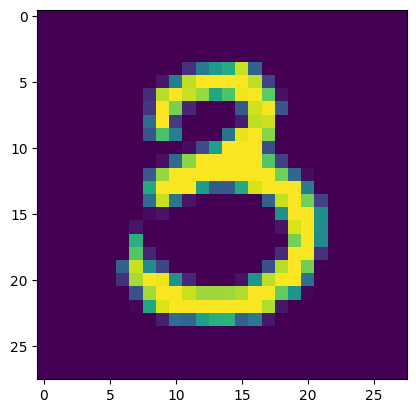

In [56]:
plt.imshow(X_test[1150])

In [57]:
np.argmax(y_predict[1150])

np.int64(3)

## 9. Module Delployment

In [58]:
model.save("image_intel.h5")

## Step 1 : Collect the Input From User

In [59]:
from PIL import Image

In [143]:
img= Image.open(r"C:\Users\Lenovo\OneDrive\Pictures\Test_Image_5_2.png")

In [144]:
img = img.convert(mode="L").resize((28,28))

In [145]:
img.size

(28, 28)

In [146]:
img = np.array(img)
img = img%255

In [147]:
pd.DataFrame(img%255)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,194,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,194,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,194,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,194,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,194,0,0,0,0,0,0,0,0,0,206,174,158,140,124,112,101,89,79,74,69,68,156,0,0,0,0
5,0,194,0,0,0,0,0,0,0,0,125,6,0,0,0,0,0,0,0,0,0,0,0,107,0,0,0,0
6,0,194,0,0,0,0,0,0,0,168,0,0,46,67,80,92,103,111,116,120,122,123,145,237,0,0,0,0
7,0,194,0,0,0,0,0,0,243,42,0,57,245,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,194,0,0,0,0,0,0,168,0,0,170,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,194,0,0,0,0,0,254,75,0,41,248,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


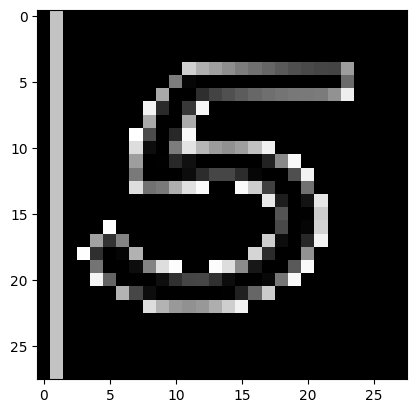

In [148]:
plt.imshow(img%255,cmap = "gray")

In [97]:
img.shape

(28, 28)

### Step 2 : Predit the Image

In [83]:
from keras.models import load_model

In [98]:
img_brain = load_model("image_intel.h5")

In [134]:
def predict_imgae(image):
    print(plt.imshow(image,cmap = "gray"))
    image = image/255.0
    image = np.expand_dims(image,axis= 0)
    print(image.shape)
    predic_img = img_brain.predict(image)
    return np.argmax(predic_img)
    

AxesImage(shape=(28, 28))
(1, 28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


np.int64(5)

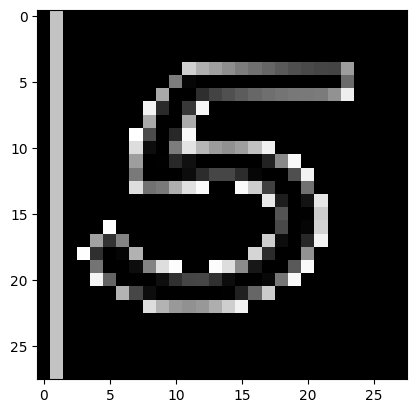

In [149]:
predict_imgae(img)

# 2 nd Menthod One Hot Encoder

## 4. Data Preparation

#### Normaile the Data

In [27]:
X_train.min(),X_test.max()

(np.uint8(0), np.uint8(255))

In [28]:
X_train = X_train/255.0
X_test = X_test/255.0

In [29]:
X_train.min(),X_test.max()

(np.float64(0.0), np.float64(1.0))

In [105]:
y_train_cat = keras.utils.to_categorical(y_train, num_classes=10)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=10)

In [107]:
y_train_cat[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

## 5. Module Building

In [30]:
from keras.models import Sequential
from keras.layers import Flatten,Dense

In [31]:
model = Sequential()

In [35]:
model.add(layer= Flatten()) ## Input Layer
model.add(layer= Dense(units = 100,activation="relu")) ## Hidden Layer 1
model.add(layer=Dense(units = 10,activation="softmax")) ## Output Layer

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [110]:
## Complie the Modile after architect'
model.compile(optimizer="rmsprop",loss="categorical_crossentropy",metrics=["categorical_accuracy"])

## 6. Module Trining | Module Test | Module Evaluation

In [111]:
model.fit( x= X_train,y= y_train_cat,batch_size = 50,epochs= 10,validation_data = (X_test,y_test_cat))

Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - categorical_accuracy: 1.0000 - loss: 1.1119e-04 - val_categorical_accuracy: 0.9776 - val_loss: 0.1295
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - categorical_accuracy: 1.0000 - loss: 9.9086e-05 - val_categorical_accuracy: 0.9785 - val_loss: 0.1297
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - categorical_accuracy: 1.0000 - loss: 9.3803e-05 - val_categorical_accuracy: 0.9785 - val_loss: 0.1297
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - categorical_accuracy: 1.0000 - loss: 7.1400e-05 - val_categorical_accuracy: 0.9780 - val_loss: 0.1297
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - categorical_accuracy: 1.0000 - loss: 7.2230e-05 - val_categorical_accuracy: 0.9780 - val_loss: 0.1306
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - categorical_accuracy: 1.0000 - loss: 6.4784e-05 - val_categorical_accuracy: 0.9784 - val_loss: 0.1311
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/ste

## 8. Module Manual Validation

In [112]:
y_predict = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [117]:
np.argmax(y_predict[1150])

np.int64(3)

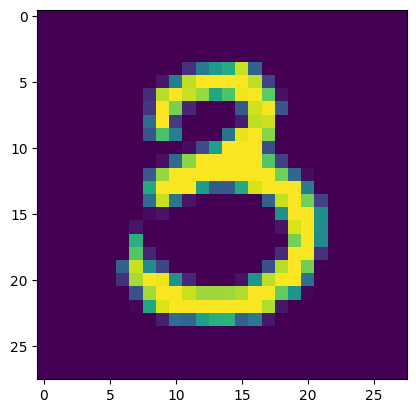

In [114]:
plt.imshow(X_test[1150])

In [115]:
np.argmax(y_predict[1150])

np.int64(3)